# LLM confidence calibration on tweet irony detection — local model, two signals (direct prob)

This notebook is a variant of [`irony_llama_100.ipynb`](irony_llama_100.ipynb) that swaps
out the JSON label-and-confidence elicitation for a **direct `P(text is ironic)` prompt**,
while keeping the **token-softmax probability signal** unchanged. Two confidence signals
from the *same local model on the same examples*:

1. **Verbalized probability** — ask the model to write a single integer in `[0, 100]`
   estimating `P(text is ironic)`. The implied label is `1 if P >= 0.5 else 0`, and the
   confidence-in-chosen-label is `max(P, 1-P)`. Same elicitation as
   [`irony_sonnet_prob.ipynb`](irony_sonnet_prob.ipynb), so the open-vs-closed comparison
   is on equal prompt footing.
2. **Token-softmax probability** — ask the model for a single-character answer (`1` or
   `0`), then read the softmax probability mass on those two tokens directly from the
   final logits. Confidence in the chosen label =
   `max(P("1"), P("0")) / (P("1") + P("0"))`.

Both signals get the same calibration treatment downstream (ECE, reliability diagram,
AUROC). The interesting question is which one tracks empirical accuracy better — the
model's *verbal estimate* of P(ironic), or the actual probability mass it places on each
answer token under a minimal prompt.

**Why this requires running locally.** The Anthropic API does not expose per-token
probabilities. To get them you have to run inference yourself; MLX is the fastest path
on Apple Silicon (direct access to logits, no separate server, sub-process loading).

## Setup

Requires `mlx-lm` (Apple Silicon only). The first call to `mlx_lm.load()` downloads the
model weights from HuggingFace — the default below is ~5GB and takes a minute or two on
first run; subsequent runs use the local cache.

Shared utilities (data loading, prompt templates, run loop, ECE / AUROC math, plots) live
in [`calib.py`](calib.py). The MLX-specific code below is what makes the token-softmax
signal possible — neither closed-API notebook can produce that.

Memory budget: the default model (Llama 3.1 8B Instruct at 4-bit) is small relative to a
32GB system — ~5GB for weights leaves plenty of room for context and KV cache. Dense
~8B models run at ~50–80 tok/s on M2 Pro, so a full pass over the 4601-example pool
takes roughly 30 minutes.

> **Note on gated weights.** Llama 3.1 is gated on HuggingFace — the first download
> requires you to have accepted Meta's license terms on
> `https://huggingface.co/meta-llama/Llama-3.1-8B-Instruct` and to be authenticated
> (`huggingface-cli login` or `HF_TOKEN` env var). Once you have access, the MLX
> community mirror inherits it.

In [1]:
# !pip install datasets mlx-lm scikit-learn numpy matplotlib

In [2]:
import os
import time

import mlx.core as mx
import numpy as np
from mlx_lm import generate, load

import calib

# config — what's specific to this run
# dense 8B at 4-bit — fits easily on 32GB and runs ~50-80 tok/s on M2 Pro.
# verify the exact repo name on huggingface.co/mlx-community before pulling.
MODEL = "mlx-community/Meta-Llama-3.1-8B-Instruct-4bit"

# subsample size; running the full 4601 takes ~30 min on M2 Pro
N_SAMPLES = 4601
N_BINS = 30
# verbalized-P(ironic) top end (model asked for integer 0-100)
SCALE = 100
SEED = 0
RESULTS_CSV = "data/irony_llama_prob.csv"

/Users/aaron/.pyenv/versions/llm_confidence/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load the data

[`cardiffnlp/tweet_eval`](https://huggingface.co/datasets/cardiffnlp/tweet_eval) config
`irony` — the SemEval-2018 Task 3 split. Zero-shot eval makes train/val/test
interchangeable, so `calib.load_irony_pool()` returns all three concatenated (4,601
examples). Label `1` = ironic (sarcasm / verbal / situational), `0` = literal.

In [3]:
ds = calib.load_irony_pool()
samples = calib.subsample(ds, N_SAMPLES, SEED)
print(f"using {len(samples)} examples (from a pool of {len(ds)})")
print(f"base rate (fraction ironic): {np.mean([s['label'] for s in samples]):.3f}")

using 4601 examples (from a pool of 4601)
base rate (fraction ironic): 0.481


## Load the model

First call downloads ~5GB from HuggingFace and takes a minute or two; subsequent runs hit
the local cache and are nearly instant.

If `RESULTS_CSV` already exists this cell skips the load entirely — the cached results
will be read straight from disk in the run cell below, and the classifier functions
defined in the next cell are never actually called.

In [4]:
if os.path.exists(RESULTS_CSV):
    print(f"cache hit: {RESULTS_CSV} exists — skipping model load")
else:
    t0 = time.time()
    model, tokenizer = load(MODEL)
    print(f"loaded {MODEL} in {time.time() - t0:.1f}s")

    # resolve the single-character token ids we'll read probabilities over.
    # tokenize the bare strings — most modern tokenizers emit "0"/"1" as single
    # tokens. if you swap in a model where they're multi-token, the prob path
    # below needs adjusting.
    ZERO_ID = tokenizer.encode("0", add_special_tokens=False)[0]
    ONE_ID = tokenizer.encode("1", add_special_tokens=False)[0]
    print(f"token ids: '0' -> {ZERO_ID}, '1' -> {ONE_ID}")

Fetching 6 files: 100%|██████████| 6/6 [00:00<00:00, 115439.56it/s]


loaded mlx-community/Meta-Llama-3.1-8B-Instruct-4bit in 2.0s
token ids: '0' -> 15, '1' -> 16


## Classify with two confidence signals

Two classifiers per example, both pulling their prompts and parsing from `calib`:

1. **Verbalized-probability path** — `calib.prob_ironic_system_prompt(SCALE)` +
   `calib.parse_prob_ironic_response`, exactly like the Anthropic `_prob` notebooks.
   The model writes a single integer 0–100, the parser thresholds at 0.5 to get the
   implied label and uses `max(p, 1-p)` for confidence-in-chosen-label.
2. **Token-softmax path** — `calib.PROB_SYSTEM` asks for a single character (`1` or
   `0`). One forward pass per example; we take the softmax of the final-position
   logits restricted to `{ZERO_ID, ONE_ID}`, and use `max(p, 1-p)` as the confidence in
   the chosen label.

`calib.run_loop` then drives both signals over the same examples and keeps only rows
where *both* parsed, so the verbal-vs-prob comparison is apples-to-apples.

> **Why normalize over only `{"0","1"}` instead of the full vocab.** With a tight
> instruction, those two tokens hold almost all the mass on the next position.
> Restricting the softmax avoids the small amount of mass on irrelevant tokens
> (whitespace, quotes) diluting the signal. For the full-vocab variant, replace the
> two-token softmax in `classify_prob` with `mx.softmax(last)[...]`.

In [5]:
def _chat_prompt(system_msg, user_msg):
    """Apply the model's chat template and return a ready-to-tokenize string."""
    return tokenizer.apply_chat_template(
        [{"role": "system", "content": system_msg}, {"role": "user", "content": user_msg}],
        tokenize=False, add_generation_prompt=True,
    )


def classify_verbal(text):
    """Verbalized: ask for an integer P(ironic) in [0, SCALE], parse via calib."""
    prompt = _chat_prompt(calib.prob_ironic_system_prompt(scale=SCALE), text)
    try:
        # short generation budget — only need ~3 chars for the integer
        body = generate(model, tokenizer, prompt=prompt, max_tokens=10, verbose=False)
        return calib.parse_prob_ironic_response(body, scale=SCALE)
    except Exception:
        return None, None


def classify_prob(text):
    """Token-softmax: single forward pass, softmax over the {'0','1'} answer tokens."""
    prompt = _chat_prompt(calib.PROB_SYSTEM, text)
    try:
        ids = mx.array(tokenizer.encode(prompt))[None, :]
        last = model(ids)[0, -1, :]
        two_probs = mx.softmax(mx.stack([last[ZERO_ID], last[ONE_ID]]))
        p_zero, p_one = float(two_probs[0]), float(two_probs[1])
        if p_zero + p_one == 0.0:
            return None, None
        label = 1 if p_one >= p_zero else 0
        conf = p_one if label == 1 else p_zero
        return label, conf
    except Exception:
        return None, None

In [6]:
results, signals = calib.run_or_load(
    samples,
    {"verbal": classify_verbal, "prob": classify_prob},
    RESULTS_CSV,
    progress_every=25,
)
agree = np.mean([r["pred_verbal"] == r["pred_prob"] for r in results])
print(f"label agreement between the two paths: {agree:.3f}")

no cache at data/irony_llama_prob.csv — running inference
25/4601 done  (0.70 ex/s, eta 108.5 min)
50/4601 done  (0.71 ex/s, eta 106.3 min)
75/4601 done  (0.71 ex/s, eta 106.4 min)
100/4601 done  (0.71 ex/s, eta 105.4 min)
125/4601 done  (0.70 ex/s, eta 105.8 min)
150/4601 done  (0.71 ex/s, eta 105.0 min)
175/4601 done  (0.71 ex/s, eta 104.4 min, 1 failures)
200/4601 done  (0.71 ex/s, eta 103.5 min, 1 failures)
225/4601 done  (0.71 ex/s, eta 102.6 min, 1 failures)
250/4601 done  (0.71 ex/s, eta 102.0 min, 1 failures)
275/4601 done  (0.71 ex/s, eta 101.2 min, 1 failures)
300/4601 done  (0.71 ex/s, eta 100.5 min, 1 failures)
325/4601 done  (0.71 ex/s, eta 99.7 min, 1 failures)
350/4601 done  (0.72 ex/s, eta 99.1 min, 1 failures)
375/4601 done  (0.72 ex/s, eta 98.4 min, 1 failures)
400/4601 done  (0.72 ex/s, eta 97.8 min, 1 failures)
425/4601 done  (0.72 ex/s, eta 97.3 min, 1 failures)
450/4601 done  (0.72 ex/s, eta 96.7 min, 1 failures)
475/4601 done  (0.72 ex/s, eta 96.0 min, 1 failures

## Metrics: ECE, reliability diagram, AUROC — both signals side-by-side

**ECE** is the average gap, per confidence bin, between mean stated confidence and
empirical accuracy. **AUROC** asks whether confidence ranks correct predictions above
incorrect ones (0.5 = no signal). The reliability diagram is the per-bin version of ECE;
since `calib.compute_metrics` and the plot helpers handle one or many signals
identically, both verbal and prob get the same treatment and the reliability cell
overlays them on a single axes.

**Note on the confidence ranges.** Both signals here are bounded in `[0.5, 1.0]` by
construction — the verbal signal because `max(P(ironic), 1-P(ironic)) >= 0.5`, the
token-softmax signal because we take `max(p, 1-p)`. The verbal signal additionally
clamps to integer percentages, so its support is the 51 values `{0.50, 0.51, …, 1.00}`.

In [7]:
metrics = calib.compute_metrics(signals, n_bins=N_BINS)
calib.print_metrics(metrics)

                            verbal        prob
accuracy:                    0.537       0.639
ECE:                         0.279       0.104
calibration AUROC:           0.548       0.634
classifier AUROC:            0.558       0.718

verbal bins:             30 equal-width over [0.50, 1.00]
prob bins:               30 equal-width over [0.50, 1.00]


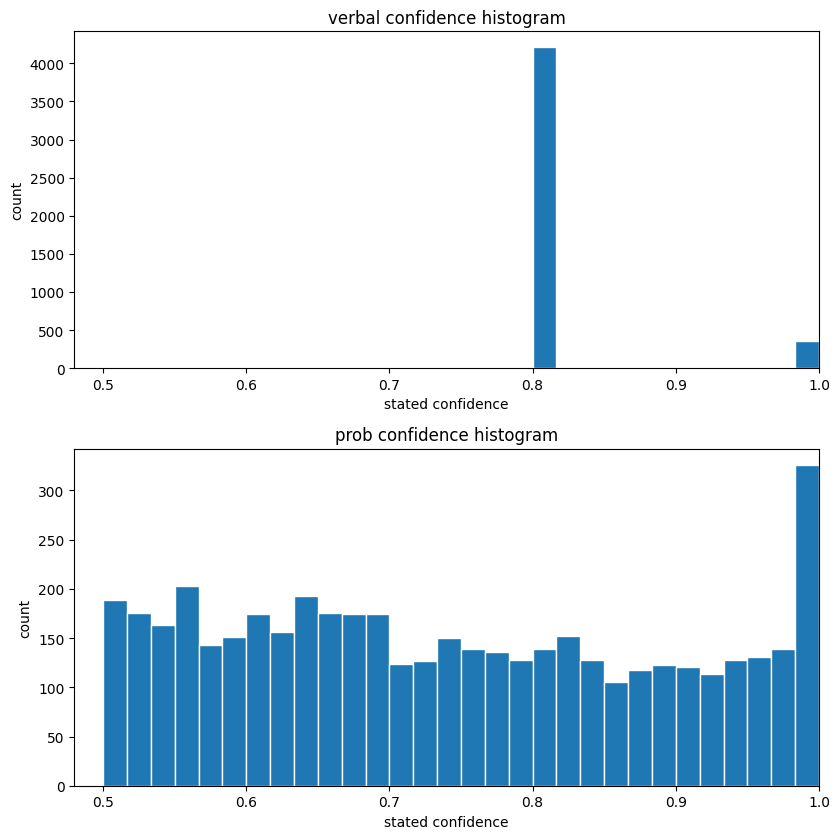

In [8]:
calib.plot_histograms(metrics)

In [9]:
calib.value_counts(signals["verbal"][0], scale=SCALE, label="verbal")
print()
calib.signal_summary(signals["prob"][0], label="prob")

verbal: 5 unique stated confidence values
   50:     1
   80:  4209
   90:    17
   95:    10
  100:   361

prob: min=0.500  median=0.731  max=1.000  (243 unique values rounded to 4dp)


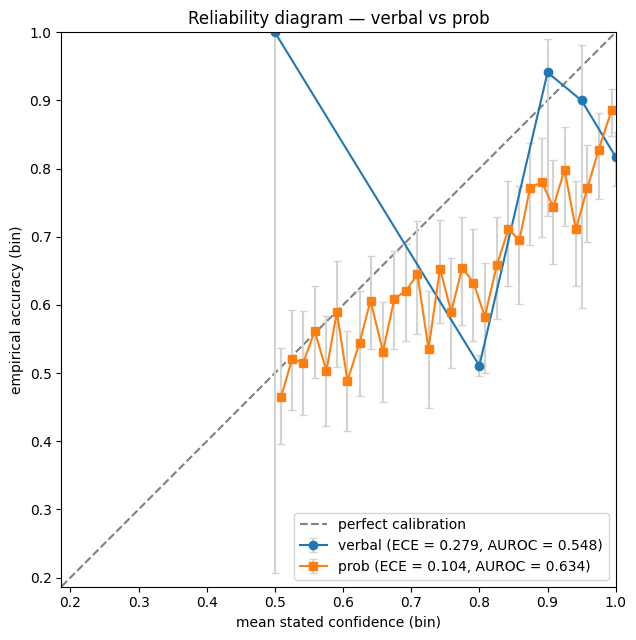

In [10]:
calib.plot_reliability(metrics)